In [ ]:
# Setup compatible con Google Colab y ejecucion local
import os
import sys
import zipfile
import subprocess
from pathlib import Path
from urllib.request import urlretrieve

IN_COLAB = 'google.colab' in sys.modules
print('Entorno Colab:', IN_COLAB)


def pip_install(packages):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + packages
    subprocess.check_call(cmd)


# Dependencias usadas en las fases del notebook.
# Nota: en Colab torch ya viene preinstalado, pero en local puede faltar.
try:
    import torch  # noqa: F401
except Exception:
    pip_install(['torch'])

pip_install([
    'numpy',
    'matplotlib',
    'pillow',
    'torchvision',
    'torchmetrics',
    'diffusers',
    'transformers',
    'accelerate',
    'tqdm',
    'scipy',
])


def download_if_missing(url, output_path):
    output_path = Path(output_path)
    if output_path.exists():
        print(f'Ya existe: {output_path}')
        return output_path
    print(f'Descargando: {url}')
    urlretrieve(url, output_path)
    print(f'Descarga completada: {output_path}')
    return output_path


def unzip_if_needed(zip_path, target_hint):
    zip_path = Path(zip_path)
    target_hint = Path(target_hint)
    if target_hint.exists():
        print(f'Ya descomprimido: {target_hint}')
        return
    print(f'Descomprimiendo: {zip_path}')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall('.')


val_zip = download_if_missing(
    'http://images.cocodataset.org/zips/val2017.zip',
    'val2017.zip'
)
ann_zip = download_if_missing(
    'http://images.cocodataset.org/annotations/annotations_trainval2017.zip',
    'annotations_trainval2017.zip'
)

unzip_if_needed(val_zip, 'val2017')
unzip_if_needed(ann_zip, 'annotations')

print('Dataset COCO listo para usar.')

--2026-03-11 18:39:03--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.191.206, 16.182.33.177, 16.15.199.45, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.191.206|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M  95.3MB/s    in 8.1s    

2026-03-11 18:39:11 (95.7 MB/s) - ‘val2017.zip’ saved [815585330/815585330]

--2026-03-11 18:39:11--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 54.231.226.137, 52.217.140.201, 54.231.170.89, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|54.231.226.137|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_tra

In [ ]:
import matplotlib.pyplot as plt
import os
import random

# Assuming images are in a 'val2017' directory after unzipping
image_dir = 'val2017'

# List some image files to verify
if os.path.exists(image_dir):
    image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(image_files)} images in {image_dir}.")
    if len(image_files) > 5:
        print("First 5 image files:", image_files[:5])
    else:
        print("All image files:", image_files)
else:
    print(f"Directory '{image_dir}' not found. Please ensure the val2017.zip was unzipped correctly.")

Found 5000 images in val2017.
First 5 image files: ['000000273198.jpg', '000000106266.jpg', '000000402765.jpg', '000000110211.jpg', '000000290768.jpg']


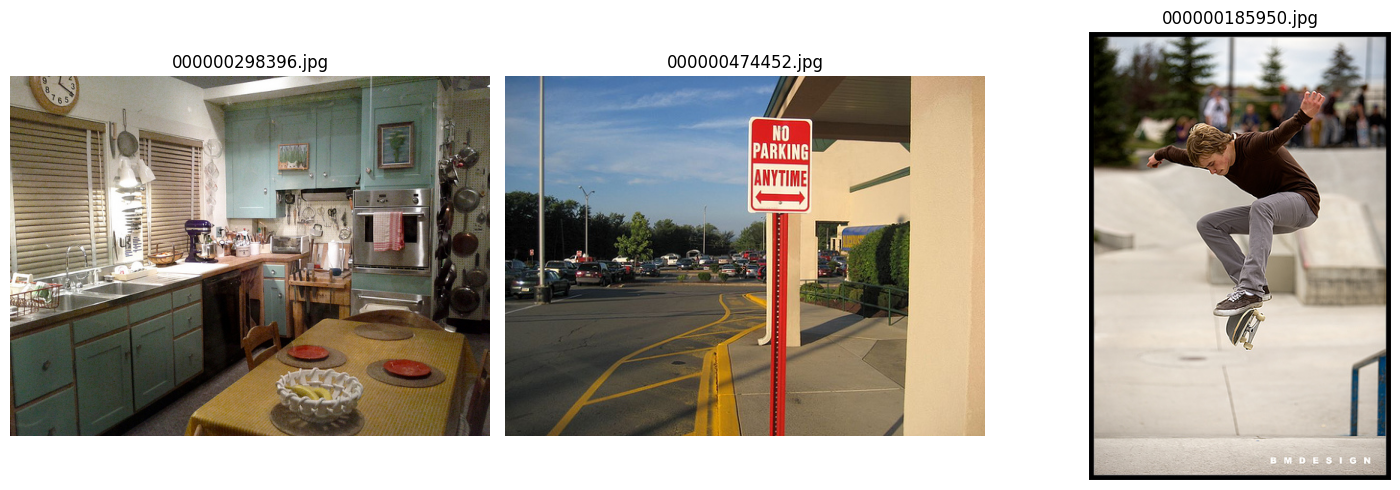

In [ ]:
num_images_to_display = 3 # You can change this number

plt.figure(figsize=(15, 5))
for i in range(num_images_to_display):
    if image_files:
        img_name = random.choice(image_files)
        img_path = os.path.join(image_dir, img_name)
        img = plt.imread(img_path)

        plt.subplot(1, num_images_to_display, i + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')
    else:
        print("No images found to display.")
        break

plt.tight_layout()
plt.show()

In [ ]:
import json
import os

# 1. Cargar el archivo de anotaciones de instancias
ann_file = 'annotations/instances_val2017.json'
with open(ann_file, 'r') as f:
    data = json.load(f)

# 2. Definir la supercategoría que quieres (ejemplo: 'animal' o 'vehicle')
target_supercategory = 'animal'

# 3. Encontrar todas las IDs de categorías que pertenecen a esa supercategoría
cat_ids = [
    cat['id'] for cat in data['categories']
    if cat['supercategory'] == target_supercategory
]

print(f"IDs encontradas para {target_supercategory}: {cat_ids}")

# 4. Encontrar las IDs de las imágenes que contienen esas categorías
image_ids = set()
for ann in data['annotations']:
    if ann['category_id'] in cat_ids:
        image_ids.add(ann['image_id'])

# 5. Obtener los nombres de los archivos de esas imágenes
# El formato de COCO suele ser 000000XXXXXX.jpg
target_images = [
    img['file_name'] for img in data['images']
    if img['id'] in image_ids
]

print(f"Total de imágenes encontradas en {target_supercategory}: {len(target_images)}")

IDs encontradas para animal: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Total de imágenes encontradas en animal: 1016


In [ ]:
supercats = set([cat['supercategory'] for cat in data['categories']])
print(supercats)

{'appliance', 'person', 'kitchen', 'sports', 'accessory', 'furniture', 'food', 'electronic', 'indoor', 'animal', 'outdoor', 'vehicle'}


In [ ]:
import shutil
from PIL import Image

output_dir = 'dataset_fase1'
os.makedirs(output_dir, exist_ok=True)

source_dir = 'val2017'
img_size = (64, 64)
max_images = 1200

seleccion = target_images[:max_images]
procesadas = 0
for img_name in seleccion:
    src = os.path.join(source_dir, img_name)
    dst = os.path.join(output_dir, img_name)
    if not os.path.exists(src):
        continue

    img = Image.open(src).convert('RGB').resize(img_size, Image.BICUBIC)
    img.save(dst, quality=95)
    procesadas += 1

print(f'Carpeta lista para entrenar: {output_dir}')
print(f'Imagenes 64x64 guardadas: {procesadas}')

¡Carpeta lista para entrenar!


## Fase I completa - DDPM lixeiro (dominio, adestramento e melloras)

Este bloque implementa a Fase I do enunciado:

1. Cargar subconxunto do dominio a 64x64.
2. Definir un DDPM lixeiro con opcion de Self-Attention.
3. Probar configuracions con Data Augmentation e distintos schedulers.
4. Xerar imaxes sinteticas e gardar pasos de denoising para avaliacion visual.

### Modo de ejecucion recomendado (Colab)

- `smoke`: prueba rapida para validar pipeline (pocos epochs y menos timesteps).
- `full`: entrenamiento mas estable para resultados de entrega.

El modo se configura en la celda de experimentos de Fase I.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

DATA_DIR = Path('dataset_fase1')
if not DATA_DIR.exists():
    print('Aviso: non existe dataset_fase1. Executa primeiro o bloque de preprocesado de dominio 64x64.')


# Reutilizadas de proyecto_2.ipynb

def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    beta_t = torch.linspace(beta_start, beta_end, timesteps)
    alpha_t = 1.0 - beta_t
    alpha_bar_t = torch.cumprod(alpha_t, dim=0)
    return beta_t, alpha_t, alpha_bar_t


def forward_diffusion(x0, t, alpha_bar_t):
    alpha_bar = alpha_bar_t[t].view(-1, 1, 1, 1)
    epsilon = torch.normal(mean=torch.zeros_like(x0), std=torch.ones_like(x0))
    x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * epsilon
    return x_t, epsilon


def sample_timesteps(batch_size, timesteps):
    return torch.randint(0, timesteps, (batch_size,))


def get_transform(use_aug=False):
    if use_aug:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])


class FolderImageDataset(Dataset):
    def __init__(self, folder, transform=None, max_items=None):
        self.folder = Path(folder)
        self.transform = transform
        exts = {'.jpg', '.jpeg', '.png'}
        paths = sorted([p for p in self.folder.iterdir() if p.suffix.lower() in exts]) if self.folder.exists() else []
        self.paths = paths[:max_items] if max_items is not None else paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, 0


def get_loader(batch_size=64, use_aug=False, max_items=None):
    ds = FolderImageDataset(DATA_DIR, transform=get_transform(use_aug=use_aug), max_items=max_items)
    if len(ds) == 0:
        raise RuntimeError('dataset_fase1 esta vacio. Xera primeiro o subconxunto 64x64.')
    print('Imaxes de adestramento:', len(ds))
    return DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=(DEVICE == 'cuda'))


def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / max(half - 1, 1))
    x = t[:, None] * freqs[None, :]
    emb = torch.cat([torch.sin(x), torch.cos(x)], dim=-1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, use_attn=False):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.use_attn = use_attn
        if use_attn:
            self.attn = nn.MultiheadAttention(out_ch, num_heads=4, batch_first=True)

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        h = h + self.skip(x)

        if self.use_attn:
            b, c, hgt, wid = h.shape
            seq = h.flatten(2).transpose(1, 2)
            seq, _ = self.attn(seq, seq, seq, need_weights=False)
            h = seq.transpose(1, 2).reshape(b, c, hgt, wid)
        return h


class TinyUNet(nn.Module):
    def __init__(self, base=64, t_dim=256, use_attn=False):
        super().__init__()
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))

        self.in_conv = nn.Conv2d(3, base, 3, padding=1)
        self.down = ResBlock(base, base * 2, t_dim, use_attn=use_attn)
        self.pool = nn.AvgPool2d(2)

        self.mid = ResBlock(base * 2, base * 2, t_dim, use_attn=use_attn)

        self.up = nn.Upsample(scale_factor=2, mode='nearest')
        self.up_block = ResBlock(base * 2, base, t_dim, use_attn=False)
        self.out = nn.Conv2d(base, 3, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_mlp(timestep_embedding(t, 256))

        x = self.in_conv(x)
        d = self.down(x, t_emb)
        m = self.mid(self.pool(d), t_emb)

        u = self.up(m)
        u = self.up_block(u, t_emb)
        return self.out(u)


class DDPM:
    def __init__(self, timesteps=200, schedule='linear'):
        self.timesteps = timesteps
        if schedule == 'cosine':
            s = 0.008
            t = torch.linspace(0, timesteps, timesteps + 1)
            f = torch.cos(((t / timesteps + s) / (1 + s)) * math.pi * 0.5) ** 2
            alpha_bar = f / f[0]
            betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
            betas = torch.clamp(betas, 1e-5, 0.999)
            alphas = 1.0 - betas
        else:
            betas, alphas, alpha_bar = linear_beta_schedule(timesteps)

        self.betas = betas.to(DEVICE)
        self.alphas = alphas.to(DEVICE)
        self.alpha_bar = alpha_bar.to(DEVICE)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            x_t, noise = forward_diffusion(x0, t, self.alpha_bar)
            return x_t, noise
        a_bar = self.alpha_bar[t][:, None, None, None]
        return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise, noise

    @torch.no_grad()
    def p_sample(self, model, x, t):
        b = x.size(0)
        t_batch = torch.full((b,), t, device=x.device, dtype=torch.long)
        eps_theta = model(x, t_batch)

        alpha_t = self.alphas[t]
        a_bar_t = self.alpha_bar[t]
        beta_t = self.betas[t]

        mean = (1 / torch.sqrt(alpha_t)) * (x - ((1 - alpha_t) / torch.sqrt(1 - a_bar_t)) * eps_theta)
        if t > 0:
            return mean + torch.sqrt(beta_t) * torch.randn_like(x)
        return mean

In [ ]:
@torch.no_grad()
def sample_images(model, ddpm, n=16, save_dir=None, save_denoising_dir=None, seed=1234):
    model.eval()
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    x = torch.randn((n, 3, 64, 64), device=DEVICE, generator=g)

    snapshot_steps = {ddpm.timesteps - 1, int(ddpm.timesteps * 0.66), int(ddpm.timesteps * 0.33), 0}
    denoise_snapshots = []

    for t in reversed(range(ddpm.timesteps)):
        x = ddpm.p_sample(model, x, t)
        if t in snapshot_steps:
            denoise_snapshots.append((t, x[0:1].detach().cpu().clone()))

    imgs = (x.clamp(-1, 1) + 1) / 2
    imgs = (imgs * 255).byte().cpu().permute(0, 2, 3, 1).numpy()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        for i in range(n):
            Image.fromarray(imgs[i]).save(save_dir / f'gen_{i:03d}.png')

    if save_denoising_dir is not None:
        save_denoising_dir.mkdir(parents=True, exist_ok=True)
        for t, snap in denoise_snapshots:
            arr = (snap[0].clamp(-1, 1) + 1) / 2
            arr = (arr * 255).byte().permute(1, 2, 0).numpy()
            Image.fromarray(arr).save(save_denoising_dir / f'step_{t:03d}.png')

    return imgs

In [ ]:
def train_ddpm(cfg):
    loader = get_loader(
        batch_size=BATCH_SIZE,
        use_aug=cfg['use_aug'],
        max_items=MAX_TRAIN_IMAGES,
    )
    model = TinyUNet(base=64, use_attn=cfg['use_attn']).to(DEVICE)
    ddpm = DDPM(timesteps=TIMESTEPS, schedule=cfg['schedule'])
    opt = torch.optim.AdamW(model.parameters(), lr=LR)

    history = []
    model.train()
    for epoch in range(cfg['epochs']):
        pbar = tqdm(loader, desc=f"{cfg['nome']} | epoch {epoch + 1}/{cfg['epochs']}")
        running = 0.0
        count = 0
        for x, _ in pbar:
            x = x.to(DEVICE)
            b = x.size(0)

            # Reutilizado de proyecto_2: sample_timesteps + forward_diffusion
            t = sample_timesteps(b, ddpm.timesteps).to(DEVICE)
            x_t, noise = ddpm.q_sample(x, t)

            pred_noise = model(x_t, t)
            loss = F.mse_loss(pred_noise, noise)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            running += loss.item() * b
            count += b
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        epoch_loss = running / max(count, 1)
        history.append(epoch_loss)
        print(f"[{cfg['nome']}] epoch={epoch + 1} loss={epoch_loss:.5f}")

    return model, ddpm, history


def save_loss_plot(histories, out_file):
    plt.figure(figsize=(8, 4))
    for name, hist in histories.items():
        plt.plot(hist, marker='o', label=name)
    plt.xlabel('Epoch')
    plt.ylabel('MSE ruido')
    plt.title('Fase I - Curvas de adestramento DDPM')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_file, dpi=180)
    plt.show()
    print('Guardado:', out_file)

In [ ]:
# Configuracion de experimentos (melloras)
RUN_MODE = 'smoke'  # cambia a 'full' para entrenamiento de entrega

if RUN_MODE == 'smoke':
    BATCH_SIZE = 32
    LR = 2e-4
    TIMESTEPS = 100
    MAX_TRAIN_IMAGES = 400
    EPOCHS_BASE = 1
    EPOCHS_MEJORA = 1
elif RUN_MODE == 'full':
    BATCH_SIZE = 64
    LR = 2e-4
    TIMESTEPS = 300
    MAX_TRAIN_IMAGES = 1200
    EPOCHS_BASE = 4
    EPOCHS_MEJORA = 4
else:
    raise ValueError("RUN_MODE debe ser 'smoke' o 'full'")

EXPERIMENTOS_FASE1 = [
    {
        'nome': 'baseline_linear',
        'use_aug': False,
        'use_attn': False,
        'schedule': 'linear',
        'epochs': EPOCHS_BASE,
    },
    {
        'nome': 'aug_attn_cosine',
        'use_aug': True,
        'use_attn': True,
        'schedule': 'cosine',
        'epochs': EPOCHS_MEJORA,
    },
]

# Fallback por si aun no se ejecuto la celda de rutas globales
if 'OUT' not in globals():
    OUT = Path('practica_2') / 'resultados'
    OUT.mkdir(parents=True, exist_ok=True)
if 'RUTAS' not in globals():
    RUTAS = {
        'reales_fase1': Path('dataset_fase1'),
        'generadas_fase1': OUT / 'fase1_generadas',
        'denoising_fase1': OUT / 'fase1_denoising',
        'cfg_fase2': OUT / 'fase2_cfg',
        'metricas': OUT / 'metricas',
    }
    for p in RUTAS.values():
        p.mkdir(parents=True, exist_ok=True)
if 'CHECKLIST' not in globals():
    CHECKLIST = {}

print('RUN_MODE:', RUN_MODE)
print('BATCH_SIZE:', BATCH_SIZE)
print('TIMESTEPS:', TIMESTEPS)
print('MAX_TRAIN_IMAGES:', MAX_TRAIN_IMAGES)
print('Experimentos definidos:')
for e in EXPERIMENTOS_FASE1:
    print(e)

resultados_fase1 = {}
loss_histories = {}
best_name = None
best_loss = float('inf')

for cfg in EXPERIMENTOS_FASE1:
    model, ddpm, hist = train_ddpm(cfg)
    resultados_fase1[cfg['nome']] = {'model': model, 'ddpm': ddpm, 'loss': hist[-1]}
    loss_histories[cfg['nome']] = hist

    if hist[-1] < best_loss:
        best_loss = hist[-1]
        best_name = cfg['nome']

print('Mellor experimento:', best_name, '| loss final:', best_loss)
save_loss_plot(loss_histories, OUT / 'fase1_training_losses.png')

best_model = resultados_fase1[best_name]['model']
best_ddpm = resultados_fase1[best_name]['ddpm']
_ = sample_images(
    best_model,
    best_ddpm,
    n=64,
    save_dir=RUTAS['generadas_fase1'],
    save_denoising_dir=RUTAS['denoising_fase1'],
)

CHECKLIST['fase1_denoising'] = True
print('Imaxes sinteticas e pasos de denoising gardados.')

# Proyecto 2 - Secciones automaticas para entrega

En este bloque se anaden las secciones faltantes solicitadas en el enunciado:

1. Fase I: grids y FID.
2. Fase II: barrido de CFG y CLIP Score.
3. Conclusiones.
4. Generacion de plantilla PDF para defensa (10-15 minutos).

In [ ]:
from pathlib import Path
import json
import math
import os
import random
import sys

import numpy as np
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules
ROOT = Path('/content') if IN_COLAB else Path('.').resolve()
OUT = ROOT / 'practica_2' / 'resultados'
OUT.mkdir(parents=True, exist_ok=True)

RUTAS = {
    'reales_fase1': ROOT / 'dataset_fase1',
    'generadas_fase1': OUT / 'fase1_generadas',
    'denoising_fase1': OUT / 'fase1_denoising',
    'cfg_fase2': OUT / 'fase2_cfg',
    'metricas': OUT / 'metricas',
}
for p in RUTAS.values():
    p.mkdir(parents=True, exist_ok=True)

CHECKLIST = {
    'fase1_grid_16v16': False,
    'fase1_denoising': False,
    'fase1_fid': False,
    'fase2_cfg_grid': False,
    'fase2_clip_score': False,
    'conclusiones': False,
    'pdf_defensa': False,
}

print('Entorno Colab:', IN_COLAB)
print('Directorio base:', ROOT)
print('Directorio de resultados:', OUT)
print('Checklist inicial:', CHECKLIST)

## Fase I - Grid comparativo (16 reales vs 16 sinteticas) y denoising

Usa estas celdas despues de generar imagenes con tu DDPM. La convencion recomendada es:

- Imagenes reales en `dataset_fase1`.
- Imagenes generadas en `practica_2/resultados/fase1_generadas`.
- Pasos de denoising en `practica_2/resultados/fase1_denoising`.

In [ ]:
from PIL import Image

def listar_imagenes(ruta):
    if not ruta.exists():
        return []
    return sorted([
        p for p in ruta.iterdir()
        if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}
    ])


def plot_grid(ruta, n=16, titulo='Grid', out_file=None, seed=42):
    imagenes = listar_imagenes(ruta)
    if len(imagenes) == 0:
        print(f'No hay imagenes en: {ruta}')
        return None

    random.seed(seed)
    picks = random.sample(imagenes, k=min(n, len(imagenes)))
    cols = 4
    rows = math.ceil(len(picks) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.flat:
        ax.axis('off')

    for ax, p in zip(axes.flat, picks):
        img = Image.open(p).convert('RGB')
        ax.imshow(img)
        ax.set_title(p.name, fontsize=8)
        ax.axis('off')

    fig.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    if out_file is not None:
        fig.savefig(out_file, dpi=180, bbox_inches='tight')
        print('Guardado:', out_file)
    plt.show()
    return fig

# Grid de reales y sinteticas (ejecutar cuando tengas generadas)
fig_reales = plot_grid(
    RUTAS['reales_fase1'],
    n=16,
    titulo='Fase I - 16 imagenes reales',
    out_file=OUT / 'fase1_grid_16_reales.png'
)
fig_generadas = plot_grid(
    RUTAS['generadas_fase1'],
    n=16,
    titulo='Fase I - 16 imagenes sinteticas',
    out_file=OUT / 'fase1_grid_16_sinteticas.png'
)

CHECKLIST['fase1_grid_16v16'] = fig_reales is not None and fig_generadas is not None
print('Checklist fase1_grid_16v16 =', CHECKLIST['fase1_grid_16v16'])

In [ ]:
# Denoising iterativo: espera archivos tipo step_000.png, step_001.png, ...

def plot_denoising_steps(ruta, max_steps=8, out_file=None):
    pasos = [p for p in listar_imagenes(ruta) if 'step' in p.stem.lower()]
    pasos = sorted(pasos)[:max_steps]
    if len(pasos) == 0:
        print('No se encontraron imagenes de denoising con patron step_*.png en', ruta)
        return None

    fig, axes = plt.subplots(1, len(pasos), figsize=(3 * len(pasos), 3))
    if len(pasos) == 1:
        axes = [axes]

    for ax, p in zip(axes, pasos):
        img = Image.open(p).convert('RGB')
        ax.imshow(img)
        ax.set_title(p.stem, fontsize=8)
        ax.axis('off')

    fig.suptitle('Fase I - Proceso iterativo de denoising', fontsize=14)
    plt.tight_layout()
    if out_file is not None:
        fig.savefig(out_file, dpi=180, bbox_inches='tight')
        print('Guardado:', out_file)
    plt.show()
    return fig

fig_denoise = plot_denoising_steps(
    RUTAS['denoising_fase1'],
    max_steps=8,
    out_file=OUT / 'fase1_denoising_steps.png'
)
CHECKLIST['fase1_denoising'] = fig_denoise is not None
print('Checklist fase1_denoising =', CHECKLIST['fase1_denoising'])

In [ ]:
# FID reutilizando funciones de proyecto_2.ipynb (Inception features + distancia de Frechet)
from scipy.linalg import sqrtm
from torchvision.models import inception_v3, Inception_V3_Weights


def cargar_imagenes_tensor(ruta, max_imgs=500):
    paths = listar_imagenes(ruta)[:max_imgs]
    if len(paths) == 0:
        return None
    xs = []
    for p in paths:
        img = Image.open(p).convert('RGB')
        arr = np.asarray(img, dtype=np.float32) / 255.0
        x = torch.from_numpy(arr).permute(2, 0, 1)
        xs.append(x)
    return torch.stack(xs, dim=0)


@torch.no_grad()
def preprocess_for_inception(images):
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    return F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)


@torch.no_grad()
def get_inception_features(images, feature_extractor, batch_size=32):
    features = []
    for i in range(0, images.shape[0], batch_size):
        batch = images[i:i + batch_size].to(DEVICE)
        batch = preprocess_for_inception(batch)
        feats = feature_extractor(batch)
        if isinstance(feats, tuple):
            feats = feats[0]
        features.append(feats.cpu())
    return torch.cat(features, dim=0).numpy()


def calculate_fid(real_features, fake_features, eps=1e-6):
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)

    sigma_real = np.cov(real_features, rowvar=False) + eps * np.eye(real_features.shape[1])
    sigma_fake = np.cov(fake_features, rowvar=False) + eps * np.eye(fake_features.shape[1])

    covmean = sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu_real - mu_fake
    return float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))


reales = cargar_imagenes_tensor(RUTAS['reales_fase1'], max_imgs=500)
generadas = cargar_imagenes_tensor(RUTAS['generadas_fase1'], max_imgs=500)

if reales is None or generadas is None:
    print('Faltan imagenes reales o generadas para FID.')
    CHECKLIST['fase1_fid'] = False
else:
    inception = inception_v3(weights=Inception_V3_Weights.DEFAULT).to(DEVICE)
    inception.fc = nn.Identity()
    inception.eval()

    real_feats = get_inception_features(reales, inception, batch_size=32)
    fake_feats = get_inception_features(generadas, inception, batch_size=32)
    fid_valor = calculate_fid(real_feats, fake_feats)

    fid_path = RUTAS['metricas'] / 'fid.json'
    with open(fid_path, 'w', encoding='utf-8') as f:
        json.dump({'fid': fid_valor}, f, indent=2)

    CHECKLIST['fase1_fid'] = True
    print('FID:', fid_valor)
    print('Guardado:', fid_path)

print('Checklist fase1_fid =', CHECKLIST['fase1_fid'])

## Fase II - CFG sweep y CLIP Score

Este bloque crea:

- Tabla visual con mismo prompt y seed variando CFG.
- Metricas CLIP Score por configuracion.

> Requiere `diffusers`, `transformers` y un backend de PyTorch con soporte para el modelo que uses.

In [ ]:
# Extraer prompts de captions de COCO para tu dominio

captions_path = Path('annotations') / 'captions_val2017.json'
instances_path = Path('annotations') / 'instances_val2017.json'

def extraer_prompts_dominio(supercategoria='animal', max_prompts=20):
    if not captions_path.exists() or not instances_path.exists():
        print('No se encontraron anotaciones de COCO en annotations/.')
        return []

    with open(instances_path, 'r', encoding='utf-8') as f:
        inst = json.load(f)
    with open(captions_path, 'r', encoding='utf-8') as f:
        caps = json.load(f)

    cat_ids = {
        c['id'] for c in inst['categories'] if c['supercategory'] == supercategoria
    }
    img_ids = {
        a['image_id'] for a in inst['annotations'] if a['category_id'] in cat_ids
    }

    prompts = [
        a['caption'] for a in caps['annotations']
        if a['image_id'] in img_ids
    ]
    prompts = [p.strip() for p in prompts if p.strip()]
    random.shuffle(prompts)
    return prompts[:max_prompts]

prompts_dominio = extraer_prompts_dominio(supercategoria='animal', max_prompts=10)
print('Prompts extraidos:', len(prompts_dominio))
for i, p in enumerate(prompts_dominio[:5], 1):
    print(f'{i}. {p}')

In [ ]:
# Generacion por barrido CFG (misma seed y prompt)

CFG_VALUES = [3.0, 5.0, 7.5, 10.0, 12.0]
PROMPT_BASE = prompts_dominio[0] if prompts_dominio else 'a dog running on grass'
SEED_BASE = 42


def generar_cfg_sweep(prompt=PROMPT_BASE, seed=SEED_BASE, cfg_values=CFG_VALUES):
    try:
        import torch
        from diffusers import StableDiffusionPipeline
    except Exception as e:
        print('No se pudo importar diffusers/torch:', e)
        print('Instala con: pip install diffusers transformers accelerate')
        return []

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_id = 'runwayml/stable-diffusion-v1-5'
    pipe = StableDiffusionPipeline.from_pretrained(model_id)
    pipe = pipe.to(device)

    out_files = []
    for cfg in cfg_values:
        g = torch.Generator(device=device).manual_seed(seed)
        image = pipe(
            prompt,
            guidance_scale=float(cfg),
            num_inference_steps=30,
            generator=g
        ).images[0]
        out_path = RUTAS['cfg_fase2'] / f'cfg_{cfg:.1f}.png'
        image.save(out_path)
        out_files.append((cfg, out_path))
        print('Generada:', out_path)

    return out_files

cfg_outputs = generar_cfg_sweep()
if len(cfg_outputs) > 0:
    cols = len(cfg_outputs)
    fig, axes = plt.subplots(1, cols, figsize=(3 * cols, 3.2))
    if cols == 1:
        axes = [axes]
    for ax, (cfg, p) in zip(axes, cfg_outputs):
        ax.imshow(Image.open(p).convert('RGB'))
        ax.set_title(f'CFG={cfg}')
        ax.axis('off')
    fig.suptitle(f'Prompt fijo, seed fija: {PROMPT_BASE[:80]}', fontsize=11)
    plt.tight_layout()
    out_fig = OUT / 'fase2_cfg_sweep.png'
    fig.savefig(out_fig, dpi=180, bbox_inches='tight')
    plt.show()
    print('Guardado:', out_fig)
    CHECKLIST['fase2_cfg_grid'] = True
else:
    CHECKLIST['fase2_cfg_grid'] = False

print('Checklist fase2_cfg_grid =', CHECKLIST['fase2_cfg_grid'])

In [ ]:
# CLIP Score para imagenes generadas frente al prompt

def clip_score_lote(prompt, image_paths):
    try:
        import torch
        from PIL import Image
        from transformers import CLIPProcessor, CLIPModel
    except Exception as e:
        print('No se pudo importar transformers/torch:', e)
        print('Instala con: pip install transformers torch')
        return None

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model_id = 'openai/clip-vit-base-patch32'
    model = CLIPModel.from_pretrained(model_id).to(device)
    processor = CLIPProcessor.from_pretrained(model_id)

    scores = []
    for p in image_paths:
        img = Image.open(p).convert('RGB')
        inputs = processor(text=[prompt], images=img, return_tensors='pt', padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
            txt = out.text_embeds
            im = out.image_embeds
            txt = txt / txt.norm(dim=-1, keepdim=True)
            im = im / im.norm(dim=-1, keepdim=True)
            score = float((txt * im).sum(dim=-1).item())
        scores.append(score)

    return {
        'scores': scores,
        'media': float(np.mean(scores)) if scores else None,
        'std': float(np.std(scores)) if scores else None,
    }

cfg_imgs = listar_imagenes(RUTAS['cfg_fase2'])
clip_stats = clip_score_lote(PROMPT_BASE, cfg_imgs) if cfg_imgs else None

if clip_stats is not None:
    clip_path = RUTAS['metricas'] / 'clip_score.json'
    with open(clip_path, 'w', encoding='utf-8') as f:
        json.dump({
            'prompt': PROMPT_BASE,
            'seed': SEED_BASE,
            'n_imagenes': len(cfg_imgs),
            'clip_score': clip_stats,
        }, f, indent=2)
    CHECKLIST['fase2_clip_score'] = True
    print('CLIP media:', clip_stats['media'])
    print('CLIP std:', clip_stats['std'])
    print('Guardado:', clip_path)
else:
    CHECKLIST['fase2_clip_score'] = False

print('Checklist fase2_clip_score =', CHECKLIST['fase2_clip_score'])